# Fourier Analysis of Basket Option Dataset

This notebook focuses on:

1. Generating a processed dataset for basket option pricing.
2. Precomputing Monte Carlo basket prices (best, worst, average).
3. Constructing a train/test split.
4. Computing the multi-dimensional Fourier spectrum of the pricing function.
5. Visualizing 2D projections of the spectrum.

The primary objective is the generation of a consistent and reproducible
dataset for basket option pricing. As an additional step, the Fourier
spectrum of the resulting pricing function is computed to inspect its
frequency structure with respect to the input features.

In [1]:
import sys
import os
from pathlib import Path
project_root = Path.cwd().parents[0]  

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from src.data_generation import Data
from src.data_generation.DataGenrator import DataGenerator
from src.data_generation.DataManager import DataManager
from src.data_generation.MLData import MLData
from src.data_generation.utils_data import TRADING_DAYS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.FourierAnalysis.compute_spectrum import compute_spectrum, extract_dominant_frequencies
from src.FourierAnalysis.plots import plot_dominant_spectrum, plot_spectrum_projection



## Data Configuration

The dataset is generated using the following parameters:

- Assets: IBM and NKE
- Time range: 2000–2025
- Rolling volatility window: 21 trading days
- Fixed maturity: 1/4 trading year
- Monte Carlo paths: 1 000 000
- Relative strike range: 0.7–1.3
- 5 strikes per observation

All random components use a fixed seed to ensure reproducibility.

In [2]:
tickers = ["IBM", "NKE"]
start_date = "2000-01-01"
end_date = "2025-01-01"
window = 21
seed = 123
fix_maturity = True
r: float = 0.0
q: float = 0.0
n_strikes_per_obs: int = 5
m_min: float = 0.7
m_max: float = 1.3
maturity_days= TRADING_DAYS/4
n_paths= 1_000_000

## Dataset Generation and Basket Pricing

Construct a `DataGenerator` instance which:

- Loads historical price data
- Computes rolling volatilities
- Computes the correlation matrix
- Generates relative strikes
- Prices basket options using Monte Carlo simulation

Prices are computed for:

- Best-of basket
- Worst-of basket
- Average basket

The processed dataset is then saved to disk for reuse.

In [ ]:
dg = DataGenerator(tickers=tickers, start_date = start_date, end_date = end_date, window = window, seed = seed, maturity_days = maturity_days, r = r, q = q, n_strikes_per_obs= n_strikes_per_obs, m_min= m_min, m_max= m_max, n_paths= n_paths)

_ =dg.price(option_type="best",use_percentage=True)
_ =dg.price(option_type="worst",use_percentage=True)
_ =dg.price(option_type="average",use_percentage=True)
dg.save()




Checking available data files...
IBM.csv exists
NKE.csv exists
Loaded data and computed statistics.
Pricing best...


## Feature Construction

The dataset is loaded via `DataManager`.

For each observation and strike, we expand the dataset such that:

- Volatilities of each asset are included
- The relative strike is included
- The corresponding basket price is attached
- The original date index is preserved

This results in a tabular representation suitable for machine learning
and frequency analysis.

In [9]:
dm = DataManager()
data= dm.load_by_params(tickers, start_date, end_date, window,maturity_days)
def build_feature_price_df(data, option_type="worst", use_percentage=True):

    # Expanded Inputs
    S0_exp, vols_exp, T_exp, m_exp, obs_idx, strike_idx = data.expand()

    # Expanded Basket Price (N*M,)
    y_exp = data.expand_prices(option_type, use_percentage)

    # Original Dates
    dates = data.prices.index.to_numpy()

    # Build DataFrame
    df = pd.DataFrame(
        vols_exp,
        columns=data.rolling_vols.columns
    )

    df["strike"] = m_exp
    df["basket_price"] = y_exp
    df["date"] = dates[obs_idx]

    df = df.set_index("date")

    return df

df = build_feature_price_df(data, option_type="worst", use_percentage=True)


df

Data loaded from /Users/moritzmaier/Uni/Basket-Option-Pricing-with-Quantum-Circuits/data/processed/IBM_NKE_2000-01-01_2025-01-01_win21_mat63.pkl


,IBM,NKE,strike,basket_price
date,,,,
2000-02-02,0.361951,0.485693,0.777448,0.133133
2000-02-02,0.361951,0.485693,1.172611,0.028451
2000-02-02,0.361951,0.485693,1.170117,0.028811
2000-02-02,0.361951,0.485693,0.704083,0.171483
2000-02-02,0.361951,0.485693,1.215620,0.023615
...,...,...,...,...
2024-12-31,0.231880,0.178990,0.706493,0.205414
2024-12-31,0.231880,0.178990,1.258302,0.002309
2024-12-31,0.231880,0.178990,0.732969,0.182053


## Train/Test Split

The dataset is split using `MLData`.

- Split mode: random (grouped by observation date)
- All strikes belonging to the same date remain in the same split
- This prevents information leakage across train and test sets

verify:

- Number of training and test samples
- Number of unique dates per split
- Zero overlap of dates between splits

In [10]:
mld = MLData(data=data,
option_type = "worst",
use_percentage = True,
)

print("Train samples:", len(mld.obs_idx_train), "Test samples:", len(mld.obs_idx_test))
print("Unique train dates:", len(np.unique(mld.obs_idx_train)))
print("Unique test dates:", len(np.unique(mld.obs_idx_test)))
print("Overlap dates:", len(set(mld.obs_idx_train).intersection(set(mld.obs_idx_test))))

Train samples: 25070 Test samples: 6270
Unique train dates: 5014
Unique test dates: 1254
Overlap dates: 0


## 2D Spectral Projection

The d-dimensional spectrum is projected onto two selected frequency axes
by summing over all other dimensions.

The resulting heatmap shows the dominant frequency interactions
between the selected input dimensions.

Normalization (if enabled) scales amplitudes to [0, 1].

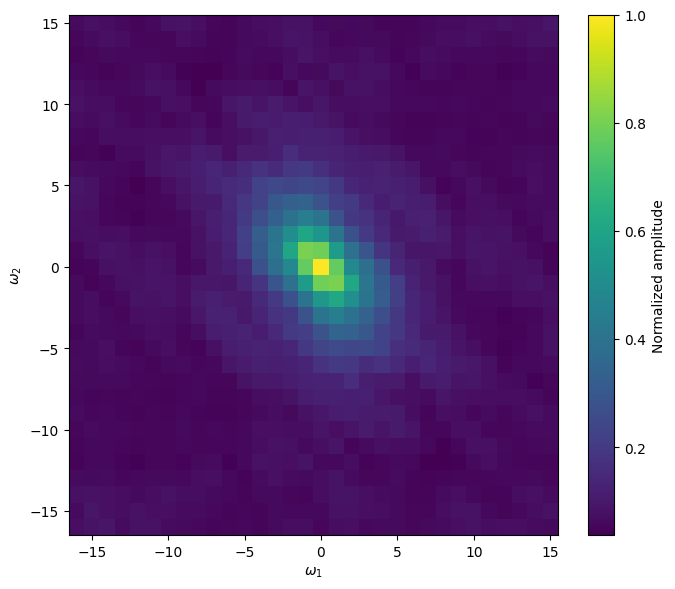

In [11]:

x, y = mld.get_train_full()
spectrum = compute_spectrum(x, y, N=32)

plot_spectrum_projection(spectrum, 0, 1, save=None)